In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA

In [3]:
import pandas as pd
df = pd.read_csv("Test (2).csv")
df.head()

,YEAR,MONTH,TYPE,Incident_Counts
0,2013,6,Vehicle Collision or Pedestrian Struck (with I...,NaN
1,2013,6,Theft of Vehicle,NaN
2,2013,6,Theft of Bicycle,NaN
3,2013,6,Theft from Vehicle,NaN
4,2013,6,Other Theft,NaN


In [4]:
df = pd.read_csv("Test (2).csv")
df.head()

,YEAR,MONTH,TYPE,Incident_Counts
0,2013,6,Vehicle Collision or Pedestrian Struck (with I...,NaN
1,2013,6,Theft of Vehicle,NaN
2,2013,6,Theft of Bicycle,NaN
3,2013,6,Theft from Vehicle,NaN
4,2013,6,Other Theft,NaN


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             162 non-null    int64  
 1   MONTH            162 non-null    int64  
 2   TYPE             162 non-null    object 
 3   Incident_Counts  0 non-null      float64
dtypes: float64(1), int64(2), object(1)
memory usage: 5.2+ KB


,YEAR,MONTH,Incident_Counts
count,162.000000,162.000000,0.0
mean,2012.333333,5.500000,NaN
std,0.472866,3.314283,NaN
min,2012.000000,1.000000,NaN
25%,2012.000000,3.000000,NaN
50%,2012.000000,5.000000,NaN
75%,2013.000000,8.000000,NaN
max,2013.000000,12.000000,NaN


In [6]:
df.isnull().sum()

,0
YEAR,0
MONTH,0
TYPE,0
Incident_Counts,162


In [7]:
df['Incident_Counts'] = 1

In [8]:
df['DATE'] = pd.to_datetime(df[['YEAR','MONTH']].assign(DAY=1))

In [9]:
crime_ts = df.groupby('DATE')['Incident_Counts'].sum()

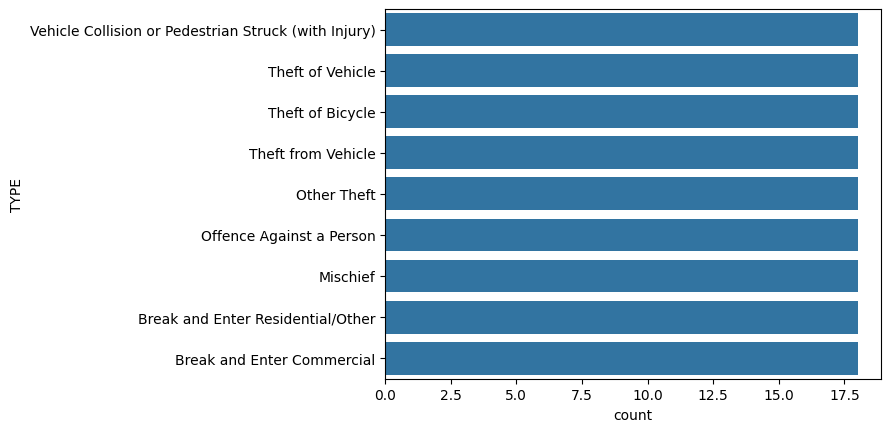

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(y='TYPE', data=df)
plt.show()

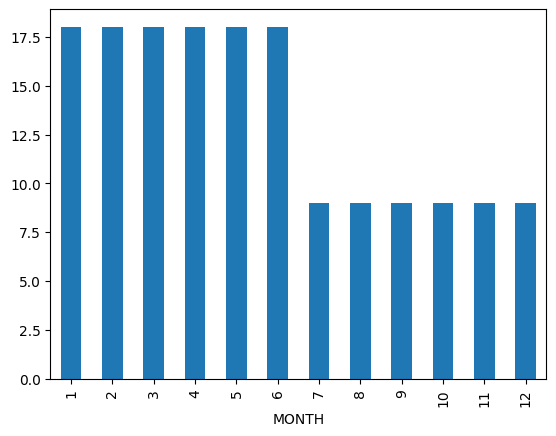

In [12]:
df.groupby('MONTH')['Incident_Counts'].sum().plot(kind='bar')
plt.show()

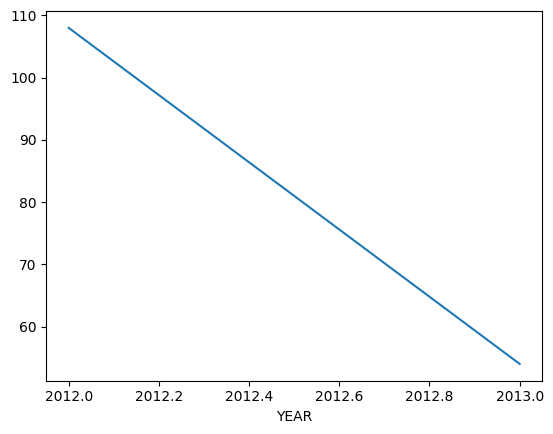

In [13]:
df.groupby('YEAR')['Incident_Counts'].sum().plot()
plt.show()

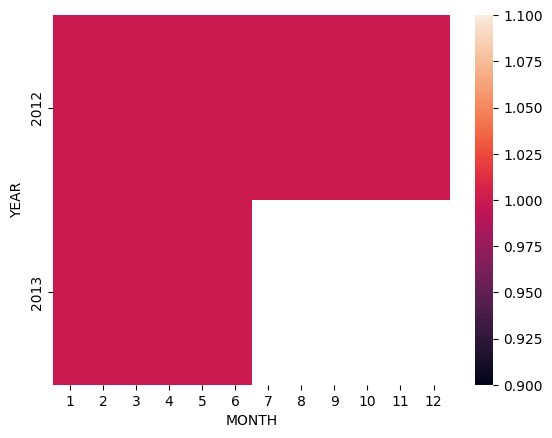

In [14]:
pivot = df.pivot_table(values='Incident_Counts', index='YEAR', columns='MONTH')

sns.heatmap(pivot)
plt.show()

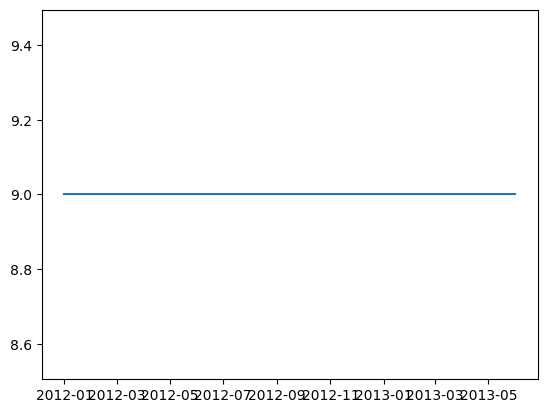

In [15]:
plt.plot(crime_ts)
plt.show()

In [17]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(crime_ts, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(12)

print(forecast)

2013-07-01    9.0
2013-08-01    9.0
2013-09-01    9.0
2013-10-01    9.0
2013-11-01    9.0
2013-12-01    9.0
2014-01-01    9.0
2014-02-01    9.0
2014-03-01    9.0
2014-04-01    9.0
2014-05-01    9.0
2014-06-01    9.0
Freq: MS, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
